# Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

import numpy as np
import torch
import torch.nn as nn

In [2]:
device = torch.device("cuda")
print("GPU:", torch.cuda.get_device_name(0))

GPU: Tesla T4


In [3]:
from pathlib import Path

DATA_ROOT = Path("/kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200")
TRAIN_ROOT = DATA_ROOT / "train"
WORDS_PATH = DATA_ROOT / "words.txt"

In [4]:
class_names = {}
with open(WORDS_PATH, "r") as f:
    for line in f:
        wnid, description = line.strip().split("\t", maxsplit=1)
        class_names[wnid] = description

class_dirs = sorted(TRAIN_ROOT.iterdir())

class_to_idx = {class_dir.name: idx for idx, class_dir in enumerate(class_dirs)}

print(f"num. de classes no dataset: {len(class_to_idx)}")
print(list(class_to_idx.items())[:5])

num. de classes no dataset: 200
[('n01443537', 0), ('n01629819', 1), ('n01641577', 2), ('n01644900', 3), ('n01698640', 4)]


In [5]:
class_dirs = sorted(TRAIN_ROOT.iterdir())
# class_to_idx = {class_dir.name: idx for idx, class_dir in enumerate(class_dirs)}

records = []
for class_dir in class_dirs:
    wnid = class_dir.name
    class_idx = class_to_idx[wnid]
    class_name = class_names[wnid]

    for image_path in sorted((class_dir / "images").glob("*.JPEG")):
        records.append({
            "path": str(image_path),
            "wnid": wnid,
            "class_idx": class_idx,
            "class_name": class_name
        })

df = pd.DataFrame(records)

print(f"imagens: {df.shape[0]}")
print(f"classes: {df['class_idx'].nunique()}")
df.head()

imagens: 100000
classes: 200


,path,wnid,class_idx,class_name
0,/kaggle/input/datasets/akash2sharma/tiny-image...,n01443537,0,"goldfish, Carassius auratus"
1,/kaggle/input/datasets/akash2sharma/tiny-image...,n01443537,0,"goldfish, Carassius auratus"
2,/kaggle/input/datasets/akash2sharma/tiny-image...,n01443537,0,"goldfish, Carassius auratus"
3,/kaggle/input/datasets/akash2sharma/tiny-image...,n01443537,0,"goldfish, Carassius auratus"
4,/kaggle/input/datasets/akash2sharma/tiny-image...,n01443537,0,"goldfish, Carassius auratus"


In [6]:
print(df.groupby("class_idx").size().describe())

count    200.0
mean     500.0
std        0.0
min      500.0
25%      500.0
50%      500.0
75%      500.0
max      500.0
dtype: float64


In [7]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(df, test_size=0.1, stratify=df["class_idx"], random_state=42)

train_df = train_df.reset_index(drop=True)
train_df = (
    train_df
    .groupby("class_idx", group_keys=False)
    .sample(n=150, random_state=42)
    .reset_index(drop=True)
)


val_df = (
    val_df
    .sample(n=10000, random_state=42)
    .reset_index(drop=True)
)

print(f"train: {train_df.shape[0]}")
print(f"validation: {val_df.shape[0]}")

train: 30000
validation: 10000


# Amostra e Data Loader

path: /kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200/train/n03891332/images/n03891332_151.JPEG
classe: parking meter
shape: (64, 64)


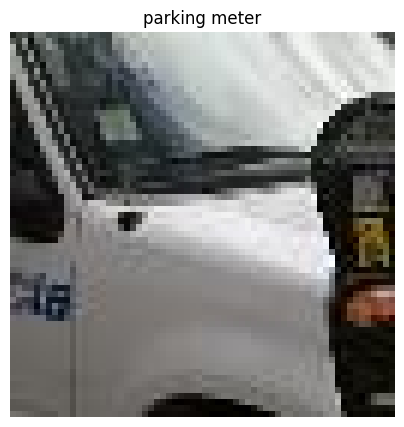

In [8]:
from PIL import Image

rndm = np.random.randint(0, train_df.shape[0])
sample = train_df.iloc[rndm]

image = Image.open(sample["path"]).convert("RGB")

print("path:", sample["path"])
print("classe:", sample["class_name"])
print("shape:", image.size)

plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.title(sample["class_name"])
plt.axis("off")
plt.show()

In [9]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class TinyImageNetDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        image = Image.open(row["path"]).convert("RGB")
        label = row["class_idx"]

        if self.transform:
            image = self.transform(image)

        return image, label

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

train_dataset = TinyImageNetDataset(train_df, transform=train_transform)
val_dataset = TinyImageNetDataset(val_df, transform=val_transform)

In [10]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

images, labels = next(iter(train_loader))

print("images:", images.shape)
print("labels:", labels.shape)

images: torch.Size([64, 3, 224, 224])
labels: torch.Size([64])


# Implementação de Camadas/Composição do Modelo

In [11]:
class Bottleneck(nn.Module):
    expansion = 4

    def __init__(self, in_channels, bottleneck_channels, stride=1):
        super().__init__()

        out_channels = bottleneck_channels * self.expansion

        self.conv1 = nn.Conv2d(
            in_channels,
            bottleneck_channels,
            kernel_size=1,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(bottleneck_channels)

        self.conv2 = nn.Conv2d(
            bottleneck_channels,
            bottleneck_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False
        )
        self.bn2 = nn.BatchNorm2d(bottleneck_channels)

        self.conv3 = nn.Conv2d(
            bottleneck_channels,
            out_channels,
            kernel_size=1,
            bias=False
        )
        
        self.bn3 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.downsample = None
        if stride != 1 or in_channels != out_channels:
            self.downsample = nn.Sequential(
                nn.Conv2d(
                    in_channels,
                    out_channels,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        out = self.conv3(out)
        out = self.bn3(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)

        return out

In [12]:
class ResNet50(nn.Module):
    def __init__(self, num_classes=200):
        super().__init__()

        self.in_channels = 64

        # Stem
        self.conv1 = nn.Conv2d(
            3,
            64,
            kernel_size=7,
            stride=2,
            padding=3,
            bias=False
        )

        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)

        self.maxpool = nn.MaxPool2d(
            kernel_size=3,
            stride=2,
            padding=1
        )

        # [3, 4, 6, 3]
        self.layer1 = self._make_layer(64, 3, stride=1)
        self.layer2 = self._make_layer(128, 4, stride=2)
        self.layer3 = self._make_layer(256, 6, stride=2)
        self.layer4 = self._make_layer(512, 3, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        self.fc = nn.Linear(
            512 * Bottleneck.expansion,
            num_classes
        )

        self._initialize_weights()

    def _make_layer(self, bottleneck_channels, blocks, stride):
        layers = [Bottleneck(self.in_channels, bottleneck_channels, stride)]

        self.in_channels = bottleneck_channels * Bottleneck.expansion
        for _ in range(1, blocks):
            layers.append(
                Bottleneck(
                    self.in_channels,
                    bottleneck_channels
                )
            )

        return nn.Sequential(*layers)

    def _initialize_weights(self):
        for module in self.modules():
            if isinstance(module, nn.Conv2d):
                nn.init.kaiming_normal_(
                    module.weight,
                    mode="fan_out",
                    nonlinearity="relu"
                )

            elif isinstance(module, nn.BatchNorm2d):
                nn.init.constant_(module.weight, 1)
                nn.init.constant_(module.bias, 0)

            elif isinstance(module, nn.Linear):
                nn.init.normal_(module.weight, 0, 0.01)
                nn.init.constant_(module.bias, 0)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)

        return self.fc(x)


# Teste Inferência/Feedforward

In [13]:
device = torch.device("cuda")
model = ResNet50(num_classes=200).to(device)

images, labels = next(iter(train_loader))
images = images.to(device)

with torch.no_grad():
    outputs = model(images)

print("input :", images.shape)
print("output:", outputs.shape)

input : torch.Size([64, 3, 224, 224])
output: torch.Size([64, 200])


In [14]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.05, momentum=0.9, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30) #controla lr durante treino

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    
    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    loss = total_loss / total
    accuracy = correct / total
    return loss, accuracy

In [15]:
@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)
        loss = criterion(outputs, labels)

        total_loss += loss.item() * images.size(0)
        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    loss = total_loss / total
    accuracy = correct / total
    return loss, accuracy

In [16]:
num_epochs = 30
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "lr": []}
best_val_acc = 0.0

print('train starting')
for epoch in range(num_epochs):
    # print(f'epoch: {epoch+1}/{num_epochs}')
    
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, val_loader, criterion, device)

    scheduler.step()
    lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["lr"].append(lr)

    print(
        f"Epoch {epoch + 1:02d}/{num_epochs}, "
        f"LR {lr:.6f}, "
        f"Train Loss {train_loss:.4f}, "
        f"Train Acc {train_acc:.4f}, "
        f"Val Loss {val_loss:.4f}, "
        f"Val Acc {val_acc:.4f}"
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_loss": val_loss,
                "val_acc": val_acc,
                "class_to_idx": class_to_idx
            },
            "/kaggle/working/best_resnet50_tinyimagenet.pth"
        )

        print(f"melhor modelo salvo: ({val_acc:.4f})")

train starting
Epoch 01/30, LR 0.049863, Train Loss 5.4371, Train Acc 0.0067, Val Loss 5.4542, Val Acc 0.0086
melhor modelo salvo: (0.0086)
Epoch 02/30, LR 0.049454, Train Loss 5.2267, Train Acc 0.0100, Val Loss 5.2242, Val Acc 0.0162
melhor modelo salvo: (0.0162)
Epoch 03/30, LR 0.048776, Train Loss 5.1019, Train Acc 0.0170, Val Loss 5.0627, Val Acc 0.0168
melhor modelo salvo: (0.0168)
Epoch 04/30, LR 0.047839, Train Loss 5.0312, Train Acc 0.0187, Val Loss 4.9581, Val Acc 0.0279
melhor modelo salvo: (0.0279)
Epoch 05/30, LR 0.046651, Train Loss 4.9243, Train Acc 0.0285, Val Loss 4.8353, Val Acc 0.0325
melhor modelo salvo: (0.0325)
Epoch 06/30, LR 0.045225, Train Loss 4.8069, Train Acc 0.0385, Val Loss 4.8734, Val Acc 0.0449
melhor modelo salvo: (0.0449)
Epoch 07/30, LR 0.043579, Train Loss 4.7032, Train Acc 0.0499, Val Loss 4.6022, Val Acc 0.0639
melhor modelo salvo: (0.0639)
Epoch 08/30, LR 0.041728, Train Loss 4.5956, Train Acc 0.0606, Val Loss 4.4885, Val Acc 0.0784
melhor modelo s

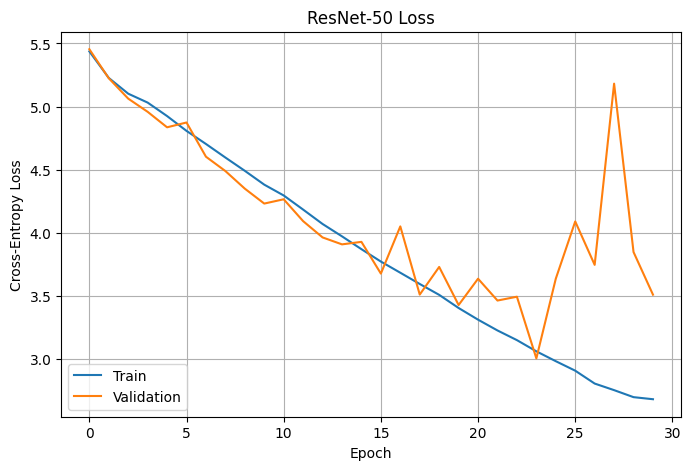

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(history["train_loss"], label="Train")
plt.plot(history["val_loss"], label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("ResNet-50 Loss")

plt.legend()
plt.grid(True)
plt.show()

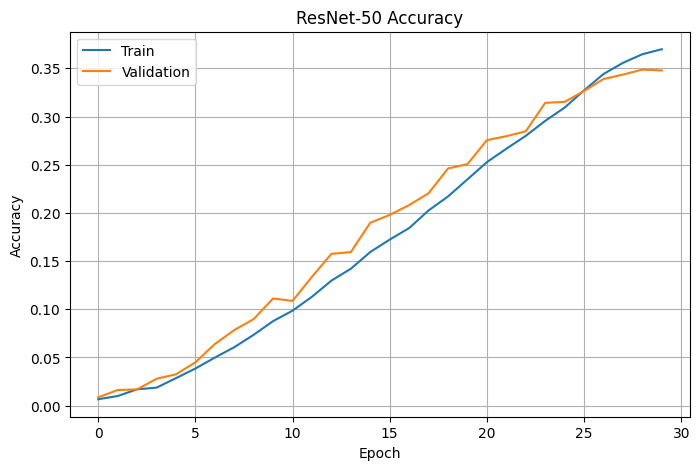

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(history["train_acc"], label="Train")
plt.plot(history["val_acc"], label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ResNet-50 Accuracy")

plt.legend()
plt.grid(True)
plt.show()

In [19]:
history_df = pd.DataFrame(history)
history_df.to_csv("/kaggle/working/training_history.csv", index=False)
